In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

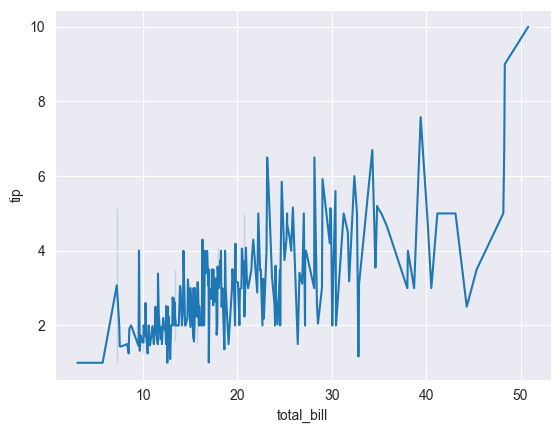

In [3]:
sns.set_style('darkgrid')
sns.lineplot(data=tips, x='total_bill', y='tip')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

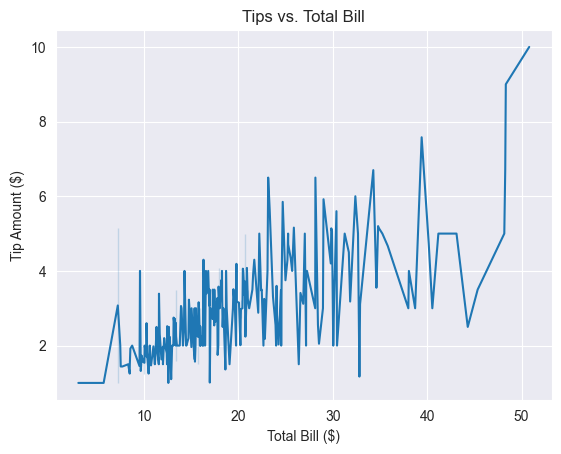

In [4]:
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')
tipgraph.set(title='Tips vs. Total Bill', 
            xlabel='Total Bill ($)', 
            ylabel='Tip Amount ($)')

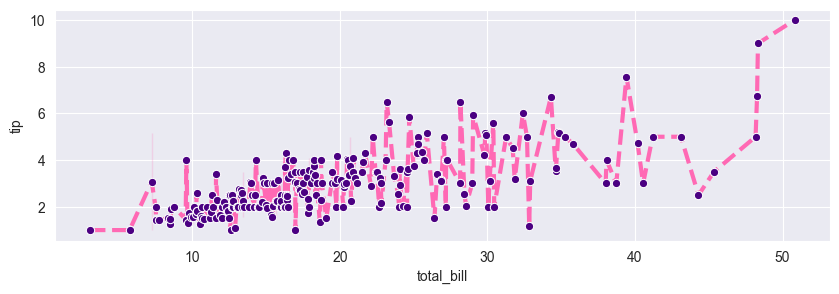

In [5]:
fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips,
                      x='total_bill',
                      y='tip',
                      color = 'hotpink',
                      linestyle = '--',
                      linewidth = 3,
                      marker = 'o',
                      markerfacecolor = 'indigo')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

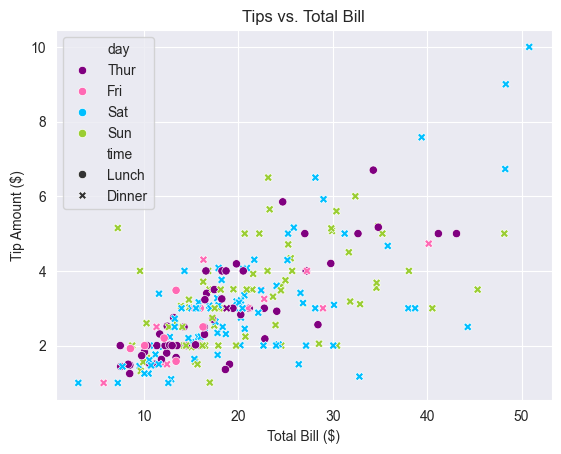

In [6]:
tipgraph = sns.scatterplot(data=tips, x='total_bill',
                        y='tip', style = 'time', hue = 
                        'day', palette = ['purple',
                        'hotpink', 'deepskyblue',
                        'yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill',
            xlabel='Total Bill ($)',
            ylabel='Tip Amount ($)')


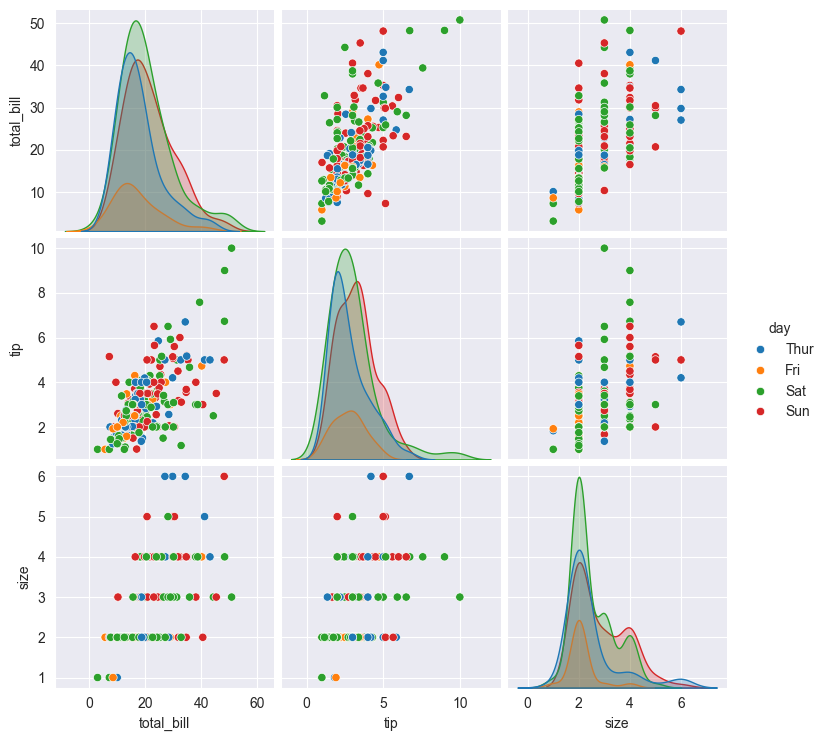

In [7]:
sns.pairplot(
      data = tips,
      hue = 'day')

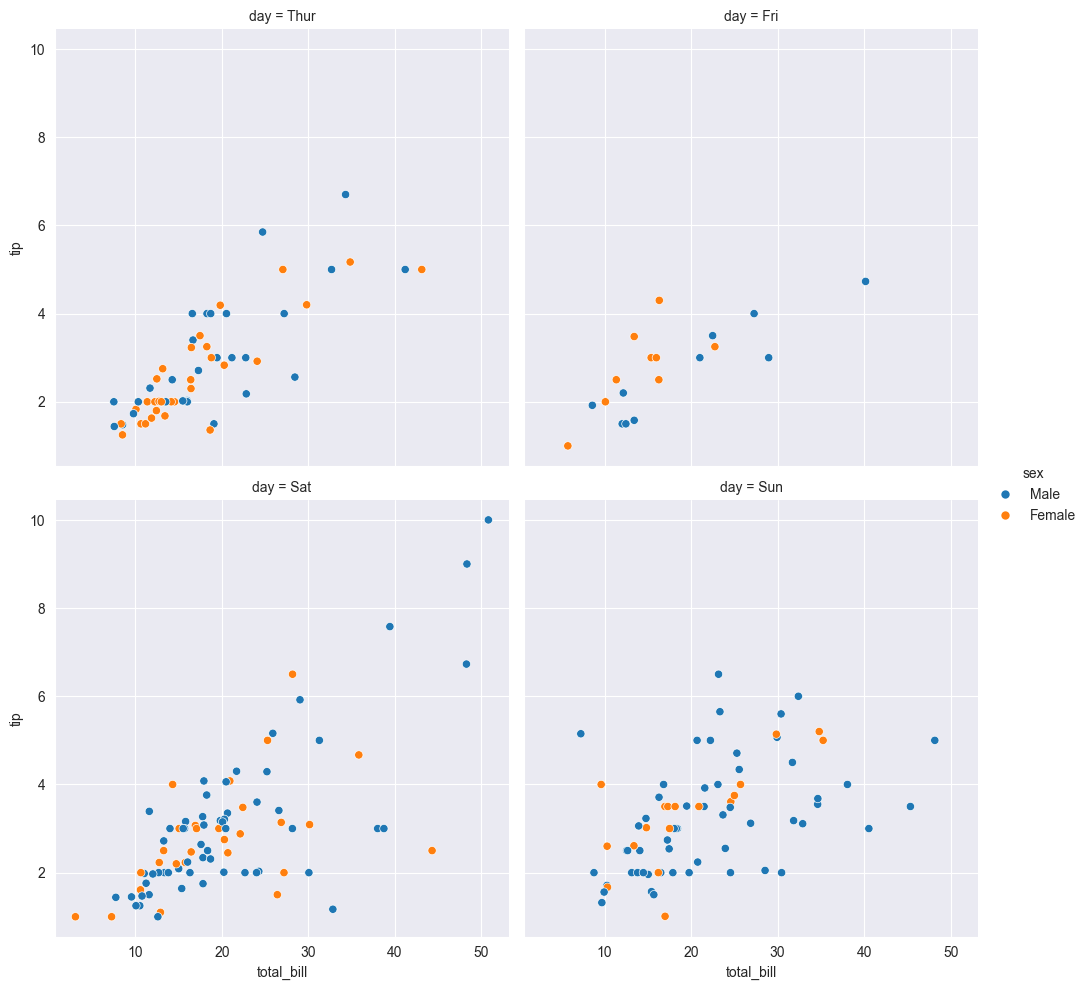

In [8]:
daysplot = sns.relplot(
            data=tips,
            x="total_bill",
            y="tip",
            hue="sex",
            col="day",
            kind="scatter",
            col_wrap=2)

In [9]:
import plotly.graph_objects as go     # 'go' is 'graph objects’

In [10]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])


In [11]:
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score")
# graph.show()
graph.write_html("./pirategraph.html")

In [12]:
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers',    # we want points for a scatter plot
    marker=dict(
        size=15,                           
        color='hotpink',                   
        opacity=1,                          
        line=dict(width=5, color='purple')  
    )))

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500, height=500)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

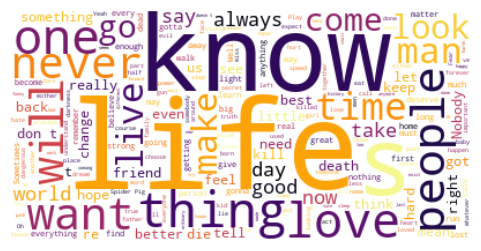

In [13]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')

# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)
# generate our wordcloud image
wordcloud = WordCloud(background_color="white", colormap = 'inferno').generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')  
ax.axis("off")


c:\Users\dtolg\Desktop\data_science_certificate_for_uoft_students\visualization\.venv_visualization\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



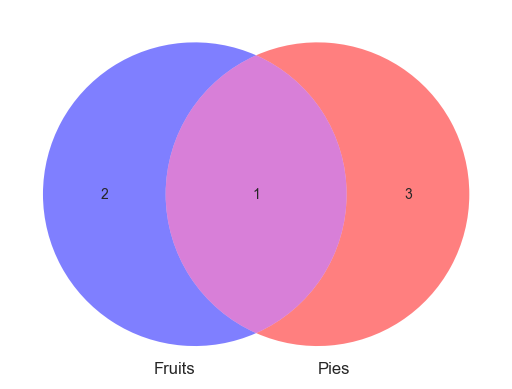

In [14]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'),
                            set_colors=("blue", "red"),
                            alpha=0.5)
plt.show()


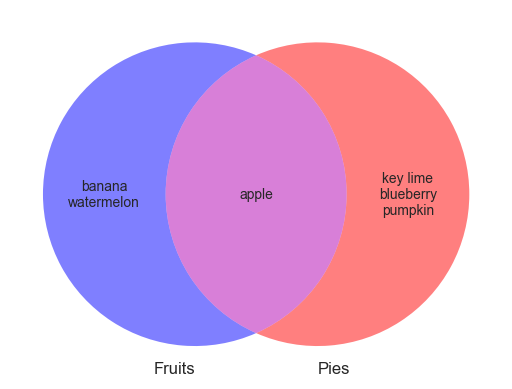

In [15]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'),
                            set_colors=("blue", "red"),
                            alpha=0.5)
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))
plt.show()
